In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
# Выводим список доступных физических устройств типа 'GPU'
gpus = tf.config.list_physical_devices('GPU')
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [2]:
# основні параметри
DATA_DIR = 'archive/train-scene classification/train' # папка де лежать всі зображення
# (папка називається трейн, але там лежать і тестові зображення)
TRAIN_CSV_PATH = 'archive/train-scene classification/train.csv'
TEST_CSV_PATH = 'archive/test_WyRytb0.csv'
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

In [5]:
# читання даних з csv
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

In [6]:
print("Тренувальні дані:")
train_df.head()

Тренувальні дані:


,image_name,label
0,0.jpg,0
1,1.jpg,4
2,2.jpg,5
3,4.jpg,0
4,7.jpg,4


In [7]:
print("\nТестові дані:")
test_df.head()


Тестові дані:


,image_name
0,3.jpg
1,5.jpg
2,6.jpg
3,11.jpg
4,14.jpg


In [8]:
# створення повних шляхів до файлів
train_df['image_path'] = train_df['image_name'].apply(lambda x: os.path.join(DATA_DIR, x))
test_df['image_path'] = test_df['image_name'].apply(lambda x: os.path.join(DATA_DIR, x))

In [9]:
# конвертація міток в рядки для категоріального режиму
train_df['label'] = train_df['label'].astype(str)

In [10]:
print("\nОновлений тренувальний DataFrame:")
train_df.head()


Оновлений тренувальний DataFrame:


,image_name,label,image_path
0,0.jpg,0,archive/train-scene classification/train\0.jpg
1,1.jpg,4,archive/train-scene classification/train\1.jpg
2,2.jpg,5,archive/train-scene classification/train\2.jpg
3,4.jpg,0,archive/train-scene classification/train\4.jpg
4,7.jpg,4,archive/train-scene classification/train\7.jpg


In [13]:
# генератор для тренувальних даних з аугментацією
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    validation_split=0.2,    
    rotation_range=20,       
    width_shift_range=0.2,   
    height_shift_range=0.2,  
    horizontal_flip=True     
)

In [14]:
# генератор для тестових даних без аугментації, тільки нормалізація
test_datagen = ImageDataGenerator(rescale=1./255)

In [15]:
# тренувальний потік
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path', 
    y_col='label',      
    subset='training',  
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=True,
    class_mode='categorical',
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

Found 13628 validated image filenames belonging to 6 classes.


In [16]:
# валідаційний потік
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    subset='validation', 
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=True,
    class_mode='categorical',
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

Found 3406 validated image filenames belonging to 6 classes.


In [17]:
# Тестовий потік
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col=None,
    batch_size=1, 
    shuffle=False, 
    class_mode=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

Found 7301 validated image filenames.


In [18]:
# кількість класів 
num_classes = len(train_generator.class_indices)
num_classes

6

In [20]:
# модель (поблоково розділено)
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2,2)))
    
model.add(layers.Conv2D(64, (3, 3)))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2,2)))

model.add(layers.Conv2D(128, (3, 3)))
model.add(layers.Activation("relu"))
model.add(layers.MaxPooling2D(pool_size=(2,2)))
 
model.add(layers.Flatten())
model.add(layers.Dense(512))
model.add(layers.Dropout(.5))
    
model.add(layers.Dense(num_classes))
model.add(layers.Activation("softmax"))

In [21]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 126, 126, 32)      896       
                                                                 
 activation_4 (Activation)   (None, 126, 126, 32)      0         
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 activation_5 (Activation)   (None, 61, 61, 64)        0         
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

In [22]:
# компіляція
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
# Навчання з генераторами
EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/20
426/426 [==============================] - 231s 530ms/step - loss: 1.0941 - accuracy: 0.5787 - val_loss: 0.9951 - val_accuracy: 0.6127
Epoch 2/20
426/426 [==============================] - 75s 177ms/step - loss: 0.8495 - accuracy: 0.6789 - val_loss: 0.7726 - val_accuracy: 0.7190
Epoch 3/20
426/426 [==============================] - 76s 179ms/step - loss: 0.7516 - accuracy: 0.7227 - val_loss: 0.6857 - val_accuracy: 0.7566
Epoch 4/20
426/426 [==============================] - 75s 176ms/step - loss: 0.7062 - accuracy: 0.7408 - val_loss: 0.6348 - val_accuracy: 0.7692
Epoch 5/20
426/426 [==============================] - 81s 190ms/step - loss: 0.6662 - accuracy: 0.7562 - val_loss: 0.6119 - val_accuracy: 0.7804
Epoch 6/20
426/426 [==============================] - 86s 202ms/step - loss: 0.6354 - accuracy: 0.7710 - val_loss: 0.6262 - val_accuracy: 0.7783
Epoch 7/20
426/426 [==============================] - 80s 189ms/step - loss: 0.6189 - accuracy: 0.7778 - val_loss: 0.6682 - val_a

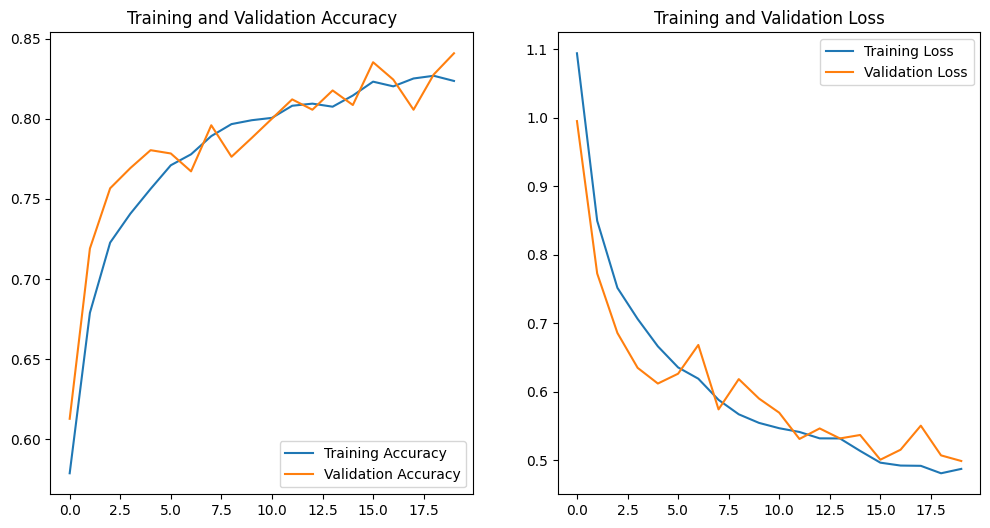

In [24]:
# статистика навчання з history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# створення фігури з двома графіками
plt.figure(figsize=(12, 6))

# графік точності
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# графік втрат
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [25]:
test_generator.reset()

# прогнози на тестовій вибірці
predictions = model.predict(test_generator, steps=test_generator.samples)

predicted_class_indices = np.argmax(predictions, axis=1)

print("Приклад перших 5 прогнозів (індекси класів):")
print(predicted_class_indices[:5])

7301/7301 [==============================] - 82s 11ms/step
Приклад перших 5 прогнозів (індекси класів):
[5 0 4 4 5]


In [27]:
# словник (індекси: назви класів)
labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())
predicted_labels = [labels[k] for k in predicted_class_indices]

class_names = {
    0: 'Buildings',
    1: 'Forests',
    2: 'Glacier',
    3: 'Mountains',
    4: 'Sea',
    5: 'Street'
}

# конвертація числових прогнозів в назви класів
predicted_labels_text = [class_names[k] for k in predicted_class_indices]

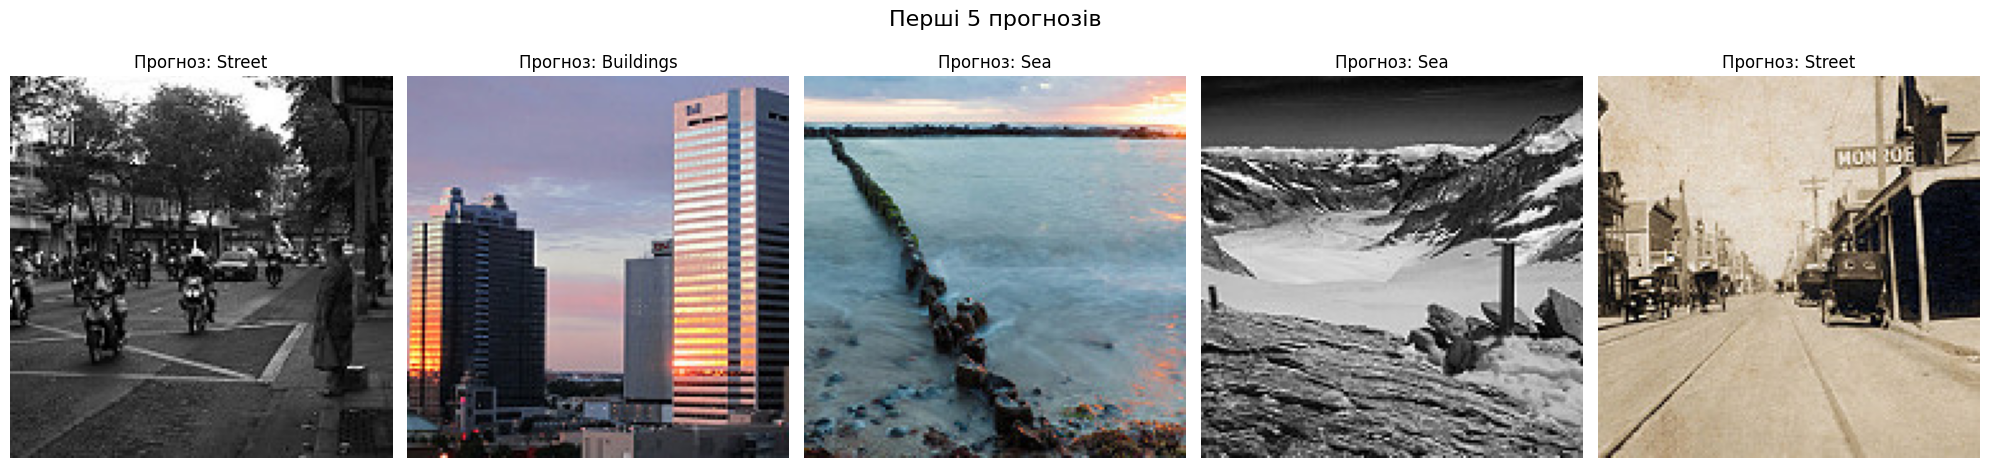

In [28]:
N_IMAGES_TO_SHOW = 5

test_generator.reset()

# фігура для візуалізації
fig, axes = plt.subplots(1, N_IMAGES_TO_SHOW, figsize=(20, 5))
fig.suptitle('Перші 5 прогнозів', fontsize=16)

for i in range(N_IMAGES_TO_SHOW):
    img_path = test_df['image_path'].iloc[i]
    img = mpimg.imread(img_path)
    predicted_label = predicted_labels_text[i]

    ax = axes[i]
    ax.imshow(img)
    ax.set_title(f"Прогноз: {predicted_label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [29]:
# DataFrame з результатами тестування
submission_df = pd.DataFrame({
    'image_name': test_df['image_name'],
    'label': predicted_labels
})

submission_df.to_csv('submission.csv', index=False)

print("\nФайл submission.csv створено успішно!")
submission_df.head()


Файл submission.csv створено успішно!


,image_name,label
0,3.jpg,5
1,5.jpg,0
2,6.jpg,4
3,11.jpg,4
4,14.jpg,5


In [32]:
# розподіл прогнозів серед класів
predictions_series = pd.Series(predicted_labels_text)

print("Статистика прогнозів на тестовій вибірці")
class_distribution = predictions_series.value_counts()

class_distribution.sort_index(inplace=True)

print(class_distribution)

Статистика прогнозів на тестовій вибірці
Buildings    1252
Forests      1176
Glacier      1161
Mountains    1368
Sea          1071
Street       1273
Name: count, dtype: int64


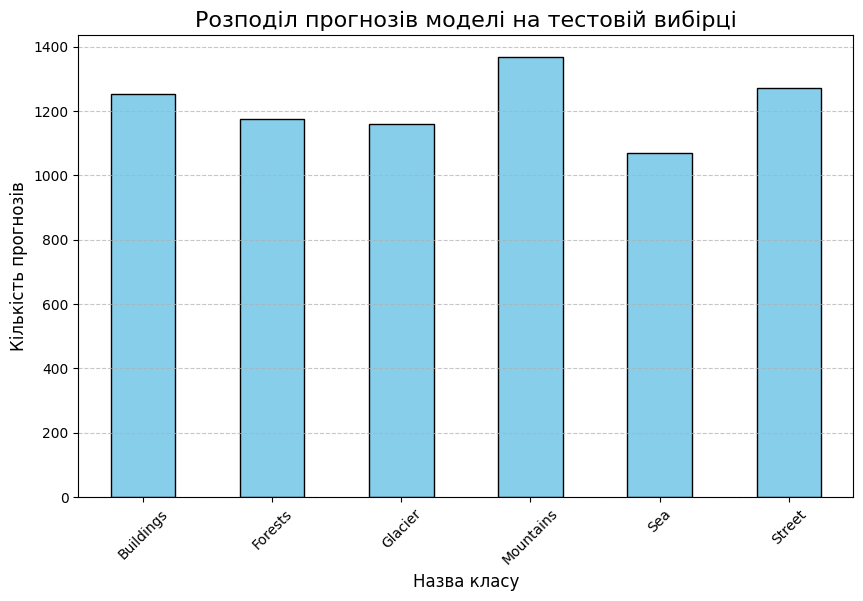

In [31]:
# Створюємо фігуру
plt.figure(figsize=(10, 6))

# 3. Будуємо стовпчикову діаграму
class_distribution.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Розподіл прогнозів моделі на тестовій вибірці', fontsize=16)
plt.xlabel('Назва класу', fontsize=12)
plt.ylabel('Кількість прогнозів', fontsize=12)
plt.xticks(rotation=45) # Повертаємо назви класів для кращої читабельності
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Показуємо графік
plt.show()

In [ ]:
loaded_model = tf.keras.models.load_model('scene_classifier_model.keras')

In [ ]:
# Створюємо генератор для тестових даних (без аугментації, тільки нормалізація)
test_datagen = ImageDataGenerator(rescale=1./255)

# Тестовий потік
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col=None,
    batch_size=1, # Зазвичай для тестування batch_size=1
    shuffle=False, # Не перемішуємо, щоб зберегти порядок
    class_mode=None,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

# Скидаємо генератор, щоб бути впевненими, що він починається з початку
test_generator.reset()

# Робимо прогнози
predictions = loaded_model.predict(test_generator, steps=test_generator.samples)

# predictions - це масив ймовірностей для кожного класу.
# Нам потрібен індекс класу з максимальною ймовірністю.
predicted_class_indices = np.argmax(predictions, axis=1)

print("Приклад перших 5 прогнозів (індекси класів):")
print(predicted_class_indices[:5])